In [17]:
import numpy as np
from scipy.signal import hilbert
from scipy.ndimage import median_filter
import cv2
import matplotlib.pyplot as plt

def reconstruct(block):

    # 减直流
    block = block - np.mean(block, axis=2, keepdims=True)

    # Hilbert包络
    analytic = hilbert(block, axis=2)
    envelope = np.abs(analytic)

    # 中值滤波
    envelope = median_filter(envelope, size=(3,3,3))

    return envelope

# -----------------------------
# 参数
# -----------------------------
shape = (1500, 1250, 2048)
file_path = "data_CT266.dat"
print("In")
# -----------------------------
# 1 读取short数组并reshape为3D
# -----------------------------
data = np.fromfile(file_path, dtype=np.int16)
data = data.reshape(shape).astype(np.float32)

Mod1 = data[:,:,0:512]
Mod2 = data[:,:,512:1024]
Mod3 = data[:,:,1024:2048]

Mod1 = reconstruct(Mod1)
print("Workflow 01")
np.save("PA_Data.npy", Mod1)

In
Workflow 01


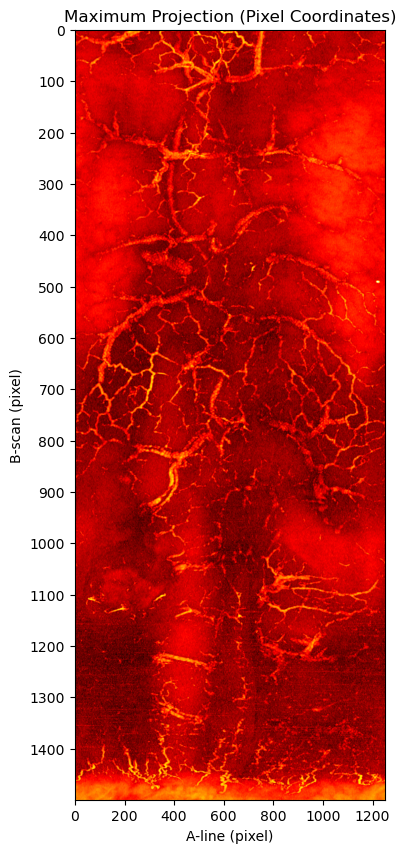

In [18]:
mip = np.max(Mod1, axis=2)

# -----------------------------
# log压缩
# -----------------------------
mip = 20 * np.log10(mip + 1e-6)

mip -= mip.min()
mip /= mip.max()
img = (mip*255).astype(np.uint8)

plt.figure(figsize=(4,10))

plt.imshow(
    img,
    cmap='hot',
    aspect='auto'   # 或 'equal'
)
plt.yticks(np.arange(0, 1500, 100))

plt.xlabel("A-line (pixel)")
plt.ylabel("B-scan (pixel)")
plt.title("Maximum Projection (Pixel Coordinates)")
plt.show()

选择肿瘤位置，给出Bscan上下界

In [1]:
Limit = [[1200,1400]]

如果上块曾运行过，则不需要重启
以下为可选

In [2]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import numpy as np
def Calculate_average_thickness(Tumor_Data):
    def aline_thickness(aline, prominence=0.05, smooth_sigma=2):
        # 平滑（去 speckle）
        aline = gaussian_filter1d(aline.astype(float), sigma=smooth_sigma)

        # 归一化
        aline = aline - aline.min()
        aline = aline / (aline.max() + 1e-8)

        # 找峰 + FWHM信息
        peaks, properties = find_peaks(
            aline,
            prominence=prominence,
            width=1
        )

        # 累加厚度
        total_thickness = 0

        for i in range(len(peaks)):
            left = properties["left_ips"][i]
            right = properties["right_ips"][i]

            width_pixel = right - left
            thickness = width_pixel

            total_thickness += thickness

        return total_thickness
    sizeZ, sizeB, sizeA = Tumor_Data.shape

    Total_thickness = np.array([aline_thickness(Tumor_Data[i, j, :])
                for i in range(sizeZ) 
                for j in range(sizeB)])
    Average_thickness = np.mean(Total_thickness)

    return Average_thickness

PA532 = np.load('PA_Data.npy')
Average_thickness = []
for r in Limit:
    Tumor_Data = PA532[r[0]:r[1],:,:]
    Average_thickness.append(Calculate_average_thickness(Tumor_Data))

print(Average_thickness)


[np.float64(194.95750725300243)]
